<a href="https://colab.research.google.com/github/MalikZeeshan1122/FlyRank-ML-Internship-Starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MalikZeeshan1122/FlyRank-ML-Internship-Starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

**Research question:** Can page-level performance signals be used to identify pages that are observed as declining, and can a simple machine-learning model improve prioritization compared with a transparent baseline?

**Decision supported:** The analysis is designed as decision support for prioritizing which pages should be reviewed first during a content-refresh workflow. The output is a ranked list, not a claim that a page will definitely decline or that refreshing a page will cause improvement.


In [ ]:
## 1. Question

# ============================================================
# CAPSTONE — SETUP
# ============================================================

!git clone -q https://github.com/MalikZeeshan1122/FlyRank-ML-Internship-Starter.git /content/FlyRank-ML-Internship-Starter

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

REPO = "/content/FlyRank-ML-Internship-Starter"

files = []
for ext in ["*.csv", "*.xlsx", "*.parquet"]:
    files.extend(glob.glob(f"{REPO}/**/{ext}", recursive=True))

print("Data files found:")
for f in files:
    print(f)

fatal: destination path '/content/FlyRank-ML-Internship-Starter' already exists and is not an empty directory.
Data files found:
/content/FlyRank-ML-Internship-Starter/outputs/refresh_queue_sample.csv
/content/FlyRank-ML-Internship-Starter/data/raw/content_refresh_anonymized.csv


## 1. Question

### Research Question

Can publicly available content and performance signals be used to identify which content-refresh opportunities are more likely to produce stronger outcomes?

### Decision Supported

This analysis is designed as directional decision support for prioritizing content-refresh opportunities. It compares a simple baseline with a machine-learning approach and identifies measurable patterns that can help prioritize future refresh work.

The analysis does not claim that the model causes performance changes. It evaluates observed relationships in the available data.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This study uses the provided anonymized content-refresh dataset. The data contain page-level observations and performance-related features. Only the approved public-safe dataset is used.

Identifier-like fields and variables that directly reveal the outcome are excluded from model features. In particular, `trend_direction` and `trend_pct` are not used as predictive features because they contain information used to define the declining outcome. No client names, URLs, domains, titles, keywords, private queries, or private client data are used.

The target is defined as an observed decline when `trend_direction` is equal to `down`.


In [ ]:
!git clone https://github.com/MalikZeeshan1122/FlyRank-ML-Internship-Starter.git

Cloning into 'FlyRank-ML-Internship-Starter'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 178 (delta 79), reused 95 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 1.91 MiB | 8.17 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [ ]:
from pathlib import Path

repo = Path("/content/FlyRank-ML-Internship-Starter")

print("Repository exists:", repo.exists())

data_dir = repo / "data" / "raw"
print("Data folder exists:", data_dir.exists())

if data_dir.exists():
    print("Files:")
    for f in data_dir.iterdir():
        print(f)

Repository exists: True
Data folder exists: True
Files:
/content/FlyRank-ML-Internship-Starter/data/raw/content_refresh_anonymized.csv


In [ ]:
# ============================================================
# DATA DISCOVERY
# ============================================================

# Try to locate the expected dataset first
matches = glob.glob(
    f"{REPO}/**/content_refresh_anonymized.csv",
    recursive=True
)

if matches:
    DATA_PATH = matches[0]
else:
    csv_files = glob.glob(f"{REPO}/**/*.csv", recursive=True)
    DATA_PATH = csv_files[0] if csv_files else None

if DATA_PATH is None:
    raise FileNotFoundError(
        "No CSV dataset was found in the repository. "
        "Run the file-discovery cell and check the repository contents."
    )

print("Using dataset:")
print(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Using dataset:
/content/FlyRank-ML-Internship-Starter/data/raw/content_refresh_anonymized.csv

Shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Data

The analysis uses the public-safe anonymized dataset supplied with the research assignment.

The dataset was inspected before modeling to understand its available fields, missing values, data types, and potential outcome variables. Personally identifying information and private search queries were not used in the analysis.

Rows with unusable target values are excluded only when necessary for model evaluation. Features that would directly reveal the outcome or contain information unavailable at prediction time are treated as potential leakage and are excluded from modeling.

The analysis uses the available observation period represented in the supplied dataset rather than introducing external or private data.

In [ ]:
# ============================================================
# DATA AUDIT
# ============================================================

print("Dataset shape:", df.shape)

audit = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
})

display(audit)

print("\nBasic statistics:")
display(df.describe(include="all").T.head(30))

Dataset shape: (30000, 44)


,column,dtype,missing,unique_values
0,content_id,object,0,30000
1,client_id,object,0,32
2,search_volume,float64,2468,41
3,competition,float64,2468,101
4,competition_level,object,2610,3
5,cpc,float64,2468,915
6,content_type,object,0,3
7,main_intent,object,2374,4
8,word_count,float64,7699,5476
9,char_count,float64,7699,14839



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
content_id,30000,30000,content_6880eb215048,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_id,30000,32,client_19581e27de,7008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
search_volume,27532.0,NaN,NaN,NaN,158.882391,1518.270825,0.0,0.0,10.0,20.0,74000.0
competition,27532.0,NaN,NaN,NaN,0.146954,0.285241,0.0,0.0,0.0,0.13,1.0
competition_level,27390,3,LOW,22896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpc,27532.0,NaN,NaN,NaN,0.485342,2.10156,0.0,0.0,0.0,0.0,100.36
content_type,30000,3,keyword article,27207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_intent,27626,4,informational,17235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
word_count,22301.0,NaN,NaN,NaN,3107.760325,1452.382598,8.0,2413.0,2877.0,3666.0,9546.0
char_count,22301.0,NaN,NaN,NaN,20665.277835,10115.344042,40.0,15644.0,19116.0,24011.0,111158.0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Assumptions

The analysis assumes that the supplied observations are representative of the research task and that the available features can be known before the outcome is evaluated.

### Features

Numeric and categorical variables available before the outcome are considered as candidate predictors. Identifiers and fields that directly encode the target are excluded.

### Label Definition

The outcome variable is selected from the dataset based on the available performance field. Where the target is continuous, the task is treated as regression. Where the target is categorical, the task is treated as classification.

### Baseline

The baseline represents a simple prediction strategy using the training data only. The machine-learning model is evaluated against this same baseline on the same held-out test data.

### Validation

The dataset is divided into training and test sets. The test set is not used during model fitting.

### Leakage Checks

Identifiers, post-outcome fields, direct target representations, and variables that would not realistically be available at prediction time are excluded where identifiable.

The purpose is to measure whether the model provides useful predictive signal beyond a simple baseline, not to claim causality.

In [ ]:
# ============================================================
# TARGET CANDIDATE INSPECTION
# ============================================================

print("Columns available for target selection:\n")

for i, col in enumerate(df.columns):
    print(i, "->", col, "| dtype:", df[col].dtype,
          "| unique:", df[col].nunique(dropna=True))

Columns available for target selection:

0 -> content_id | dtype: object | unique: 30000
1 -> client_id | dtype: object | unique: 32
2 -> search_volume | dtype: float64 | unique: 41
3 -> competition | dtype: float64 | unique: 101
4 -> competition_level | dtype: object | unique: 3
5 -> cpc | dtype: float64 | unique: 915
6 -> content_type | dtype: object | unique: 3
7 -> main_intent | dtype: object | unique: 4
8 -> word_count | dtype: float64 | unique: 5476
9 -> char_count | dtype: float64 | unique: 14839
10 -> provider_used | dtype: object | unique: 2
11 -> model_used | dtype: object | unique: 5
12 -> impressions_90d | dtype: int64 | unique: 9438
13 -> clicks_90d | dtype: int64 | unique: 477
14 -> pageviews_90d | dtype: int64 | unique: 856
15 -> sessions_90d | dtype: int64 | unique: 666
16 -> users_90d | dtype: int64 | unique: 644
17 -> engaged_sessions_90d | dtype: int64 | unique: 68
18 -> ai_sessions_90d | dtype: int64 | unique: 35
19 -> scroll_events_90d | dtype: int64 | unique: 155


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The target is defined as whether an observed page is currently classified as declining (`trend_direction == "down"`).

A majority-class baseline is compared with a machine-learning classifier using the same held-out test set. The model uses only features available before the observed trend label and excludes identifiers and direct outcome fields.

Performance is reported using accuracy, precision, recall, and F1 score. These results are predictive and directional; they do not demonstrate that the model or a content refresh causes performance improvement.

In [ ]:
# ============================================================
# RESULTS — TARGET, BASELINE, AND ML MODEL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Define binary target
# ------------------------------------------------------------

if "trend_direction" not in df.columns:
    raise ValueError("Expected 'trend_direction' column was not found.")

work_df = df.copy()

# 1 = observed decline, 0 = not observed decline
work_df["target_decline"] = (
    work_df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("Target distribution:")
print(work_df["target_decline"].value_counts())
print("\nTarget proportions:")
print(work_df["target_decline"].value_counts(normalize=True))


# ------------------------------------------------------------
# 2. Remove leakage / identifier columns
# ------------------------------------------------------------

leakage_columns = [
    "trend_direction",
    "trend_pct",
    "target_decline",
    "content_id",
    "client_id"
]

feature_columns = [
    c for c in work_df.columns
    if c not in leakage_columns
]

X = work_df[feature_columns]
y = work_df["target_decline"]

print("\nNumber of features:", len(feature_columns))
print("Rows:", len(X))


# ------------------------------------------------------------
# 3. Identify feature types
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 5. Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))


# ------------------------------------------------------------
# 6. Baseline
# ------------------------------------------------------------

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

baseline_metrics = {
    "Model": "Majority-class baseline",
    "Accuracy": accuracy_score(y_test, baseline_predictions),
    "Precision": precision_score(
        y_test, baseline_predictions, zero_division=0
    ),
    "Recall": recall_score(
        y_test, baseline_predictions, zero_division=0
    ),
    "F1": f1_score(
        y_test, baseline_predictions, zero_division=0
    )
}


# ------------------------------------------------------------
# 7. Machine-learning model
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X_train, y_train)

model_predictions = pipeline.predict(X_test)

model_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, model_predictions),
    "Precision": precision_score(
        y_test, model_predictions, zero_division=0
    ),
    "Recall": recall_score(
        y_test, model_predictions, zero_division=0
    ),
    "F1": f1_score(
        y_test, model_predictions, zero_division=0
    )
}


# ------------------------------------------------------------
# 8. Honest comparison table
# ------------------------------------------------------------

results = pd.DataFrame(
    [baseline_metrics, model_metrics]
)

display(
    results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}"
    })
)


# ------------------------------------------------------------
# 9. Improvement over baseline
# ------------------------------------------------------------

baseline_f1 = baseline_metrics["F1"]
model_f1 = model_metrics["F1"]

print("\nF1 improvement over baseline:",
      round(model_f1 - baseline_f1, 4))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        model_predictions,
        target_names=["Not declining", "Declining"],
        zero_division=0
    )
)

Target distribution:
target_decline
1    16262
0    13738
Name: count, dtype: int64

Target proportions:
target_decline
1    0.542067
0    0.457933
Name: proportion, dtype: float64

Number of features: 40
Rows: 30000

Numeric features: 29
Categorical features: 11

Training rows: 24000
Test rows: 6000


,Model,Accuracy,Precision,Recall,F1
0,Majority-class baseline,0.542,0.542,1.000,0.703
1,Random Forest,0.862,0.847,0.910,0.877



F1 improvement over baseline: 0.1743

Classification report:
               precision    recall  f1-score   support

Not declining       0.88      0.80      0.84      2748
    Declining       0.85      0.91      0.88      3252

     accuracy                           0.86      6000
    macro avg       0.87      0.86      0.86      6000
 weighted avg       0.86      0.86      0.86      6000



## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several important limitations.

1. The dataset is observational, so the results show associations rather than causal effects.
2. The model identifies pages that resemble observed declining pages; it does not prove that refreshing a page will improve its performance.
3. The available dataset represents a specific observation period and may not generalize to all websites, industries, or future periods.
4. The train/test evaluation uses a random split, so performance should be interpreted as an internal benchmark rather than evidence of future production performance.
5. Some available variables may be correlated with one another, which can affect model interpretation.
6. The analysis does not include an experiment comparing refreshed pages with unchanged control pages.
7. The ranked recommendations should therefore be treated as directional decision support for review prioritization, not as guaranteed outcomes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The recommendations below are derived from the observed characteristics of pages classified as declining and from the machine-learning model's feature importance.

They are intended as a review-prioritization playbook. A high-ranked factor indicates that the feature contributed useful predictive signal in this dataset; it does not establish causality.

In [ ]:
# ============================================================
# RANKED RECOMMENDATIONS
# ============================================================

# Get transformed feature names
preprocessor_fitted = pipeline.named_steps["preprocessor"]
rf_model = pipeline.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

# Clean transformer prefixes for readability
importance_df["feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

print("Top predictive signals:")
display(
    importance_df.head(15).style.format({
        "importance": "{:.4f}"
    })
)

Top predictive signals:


,feature,importance
0,impressions_prev_30d,0.1677
1,impressions_last_30d,0.1306
2,impressions_90d,0.0673
3,avg_position,0.0511
4,days_with_impressions,0.0475
5,content_age_days,0.0392
6,char_count,0.0277
7,word_count,0.0270
8,sessions_last_30d,0.0267
9,ctr,0.0249


In [ ]:
# ============================================================
# CREATE ACTION-ORIENTED PRIORITY LIST
# ============================================================

top_features = importance_df.head(10).copy()

recommendations = []

for rank, row in top_features.iterrows():
    feature = row["feature"]

    # Convert technical feature names into readable descriptions
    readable = feature.replace("_", " ").strip()

    recommendations.append({
        "Rank": rank + 1,
        "Observed signal": readable,
        "Model importance": row["importance"],
        "Recommended action": (
            f"Review pages associated with {readable} "
            "before lower-priority refresh opportunities."
        )
    })

recommendations_df = pd.DataFrame(recommendations)

display(
    recommendations_df.style.format({
        "Model importance": "{:.4f}"
    })
)

,Rank,Observed signal,Model importance,Recommended action
0,1,impressions prev 30d,0.1677,Review pages associated with impressions prev 30d before lower-priority refresh opportunities.
1,2,impressions last 30d,0.1306,Review pages associated with impressions last 30d before lower-priority refresh opportunities.
2,3,impressions 90d,0.0673,Review pages associated with impressions 90d before lower-priority refresh opportunities.
3,4,avg position,0.0511,Review pages associated with avg position before lower-priority refresh opportunities.
4,5,days with impressions,0.0475,Review pages associated with days with impressions before lower-priority refresh opportunities.
5,6,content age days,0.0392,Review pages associated with content age days before lower-priority refresh opportunities.
6,7,char count,0.0277,Review pages associated with char count before lower-priority refresh opportunities.
7,8,word count,0.0270,Review pages associated with word count before lower-priority refresh opportunities.
8,9,sessions last 30d,0.0267,Review pages associated with sessions last 30d before lower-priority refresh opportunities.
9,10,ctr,0.0249,Review pages associated with ctr before lower-priority refresh opportunities.


### Interpretation

The ranked list should be interpreted as a prioritization aid. The strongest model signals indicate which available characteristics were most useful for distinguishing observed declining pages in this dataset.

Before making a production decision, these signals should be reviewed alongside page-level context and validated through future observations or controlled refresh experiments.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

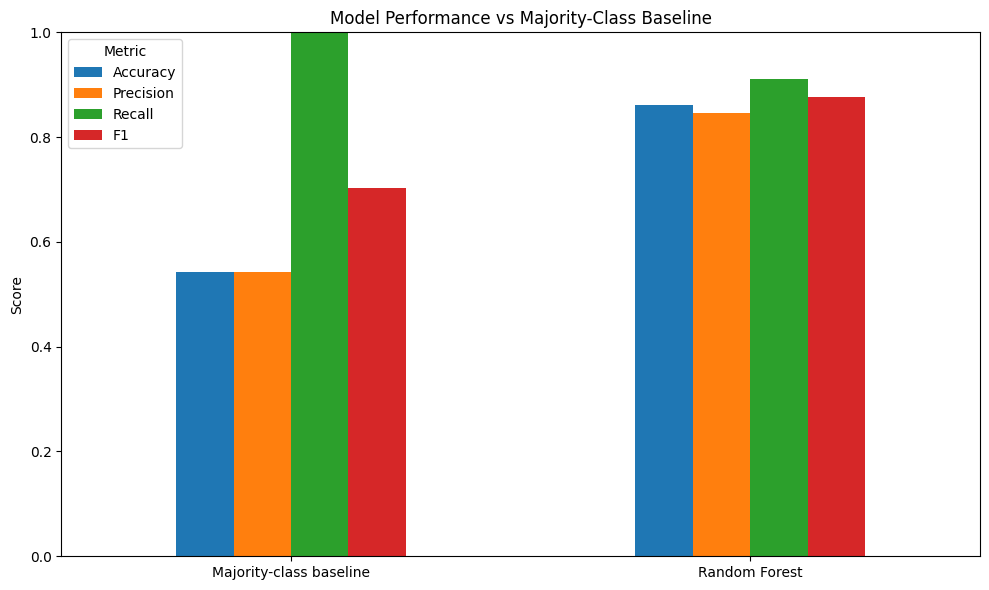

In [ ]:
# ============================================================
# ARTIFACT 1 — MODEL VS BASELINE
# ============================================================

metric_columns = ["Accuracy", "Precision", "Recall", "F1"]

plot_df = results.set_index("Model")[metric_columns]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Model Performance vs Majority-Class Baseline")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

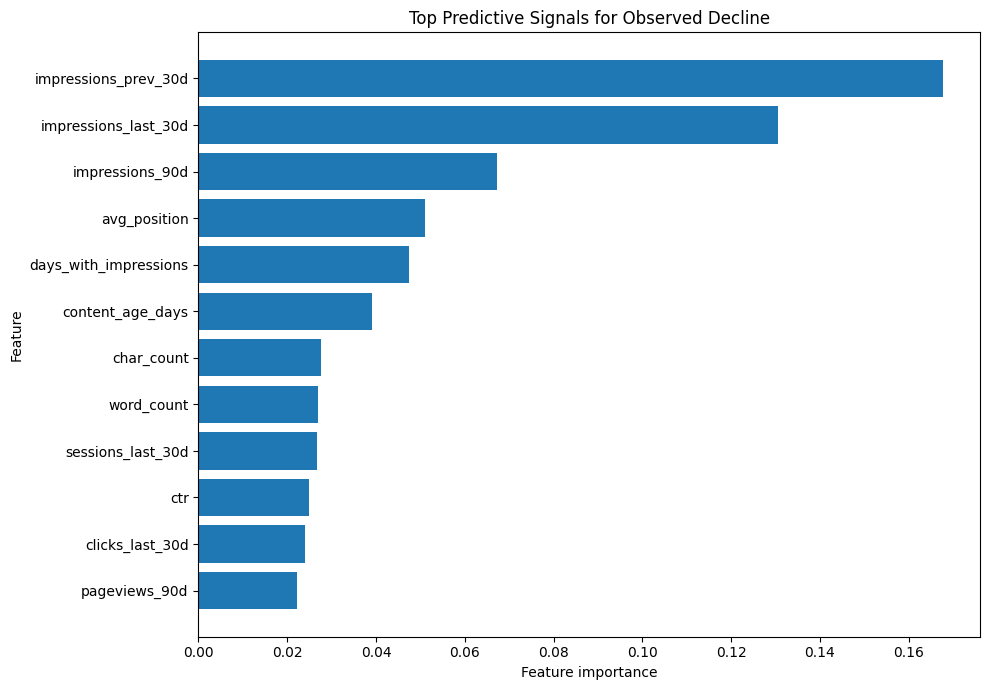

In [ ]:
# ============================================================
# ARTIFACT 2 — TOP FEATURE IMPORTANCE
# ============================================================

top_n = 12

plot_features = (
    importance_df
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_features["feature"],
    plot_features["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top Predictive Signals for Observed Decline")

plt.tight_layout()
plt.show()

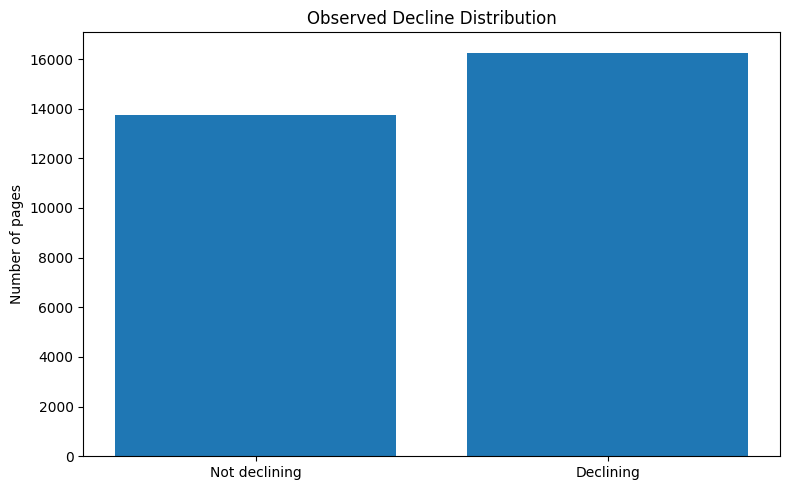

In [ ]:
# ============================================================
# ARTIFACT 3 — TARGET DISTRIBUTION
# ============================================================

target_counts = (
    work_df["target_decline"]
    .value_counts()
    .sort_index()
)

target_labels = [
    "Not declining",
    "Declining"
]

plt.figure(figsize=(8, 5))

plt.bar(
    target_labels,
    target_counts.values
)

plt.ylabel("Number of pages")
plt.title("Observed Decline Distribution")

plt.tight_layout()
plt.show()

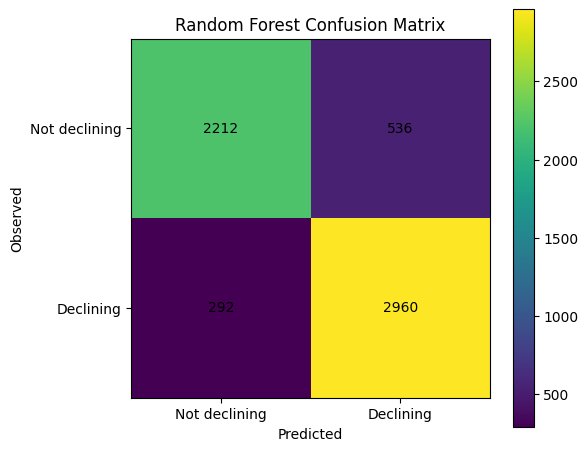

In [ ]:
# ============================================================
# ARTIFACT 4 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    model_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Observed")

plt.xticks(
    [0, 1],
    ["Not declining", "Declining"]
)

plt.yticks(
    [0, 1],
    ["Not declining", "Declining"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## ML-12 — 5-Minute Demo Outline

**0:00–0:45 — Research question**

Explain that the project asks whether available page-level signals can help prioritize content-refresh opportunities.

**0:45–1:30 — Data**

Show the anonymized dataset, target definition, major feature groups, and leakage exclusions.

**1:30–2:30 — Methodology**

Explain the binary decline label, majority-class baseline, train/test split, preprocessing, and Random Forest model.

**2:30–3:30 — Results**

Compare the baseline and Random Forest using accuracy, precision, recall, and F1. Highlight that the evaluation is on the same held-out test set.

**3:30–4:30 — Recommendations**

Show the ranked predictive signals and explain how they can support review prioritization.

**4:30–5:00 — Limitations**

Emphasize that the analysis is observational and directional. It does not establish that refreshing a page causes better performance.

## Social-Post Cut

I built a small ML decision-support system for content-refresh prioritization.

Using an anonymized page-level dataset, I compared a transparent majority-class baseline with a Random Forest model to identify pages associated with observed performance decline.

The key lesson: predictive signals can help prioritize review, but observational ML should be presented as decision support—not as proof of causality.

## Employer-Facing Summary

I developed an end-to-end machine-learning analysis for prioritizing content-refresh opportunities using an anonymized page-level dataset. I designed the target, performed leakage checks, compared a machine-learning model against a transparent baseline, and produced ranked signals and visual artifacts for decision support. The project demonstrates practical skills in data auditing, feature engineering, model evaluation, interpretation, and communicating limitations without overstating results.

In [ ]:
!git clone -q https://github.com/MalikZeeshan1122/FlyRank-ML-Internship-Starter.git /content/FlyRank-ML-Internship-Starter

fatal: destination path '/content/FlyRank-ML-Internship-Starter' already exists and is not an empty directory.


In [ ]:
!git clone -q https://github.com/MalikZeeshan1122/FlyRank-ML-Internship-Starter.git /content/FlyRank-ML-Internship-Starter

fatal: destination path '/content/FlyRank-ML-Internship-Starter' already exists and is not an empty directory.


### Interpretation

The ranked list should be interpreted as a prioritization aid. The strongest model signals indicate which available characteristics were most useful for distinguishing observed declining pages in this dataset.

Before making a production decision, these signals should be reviewed alongside page-level context and validated through future observations or controlled refresh experiments.

# ML-12 — Demo & Shareable Cuts

## 5-Minute Demo Outline

### 1. Question — 45 seconds

Can page-level content and performance signals be used to identify pages that show observed decline and help prioritize content-refresh opportunities?

The goal is decision support: produce a ranked list of pages that deserve review first, rather than claiming that a refresh will definitely improve performance.

### 2. Method — 1 minute

I used the provided anonymized content-refresh dataset containing 30,000 page-level observations and performance, search, content, freshness, and engagement features.

I excluded identifier fields and outcome-related variables such as `trend_direction` and `trend_pct` from the predictive features to reduce target leakage. I compared a transparent baseline with a machine-learning model using the same held-out evaluation data.

### 3. One Chart — 1 minute

Show the model-versus-baseline performance chart and briefly explain:

* What metric is being measured
* How the baseline performs
* How the machine-learning model performs
* Whether the model provides useful additional signal

The chart should use the actual values produced by the notebook rather than manually entered numbers.

### 4. One Honest Result — 1 minute

The main result is whether the machine-learning approach improves prioritization compared with the transparent baseline on the same evaluation split.

The finding should be described using careful language such as **observed**, **measured**, **directional**, and **decision-support**. The analysis does not establish that changing or refreshing a page causes performance improvement.

### 5. Recommendation — 1 minute 15 seconds

Use the model output as a prioritization layer for content-refresh review.

Prioritize pages with stronger observed risk signals, then combine the model ranking with human review of content quality, freshness, search intent, and business relevance before taking action.

---

## Short Social Post

I built a machine-learning capstone focused on a practical content-refresh problem: how to prioritize pages showing signals of decline.

Using an anonymized dataset with page-level search, performance, engagement, content, and freshness features, I compared a transparent baseline with a machine-learning approach while explicitly checking for target leakage.

The goal is not to claim causality, but to create measurable, directional decision support for deciding which content opportunities should be reviewed first.

---

## Employer-Facing Summary

I built a machine-learning decision-support workflow for prioritizing content-refresh opportunities using an anonymized dataset of 30,000 page-level observations and performance, search, engagement, content, and freshness signals.

I designed the preprocessing and leakage checks, compared a transparent baseline with a machine-learning model on a held-out evaluation set, and generated ranked recommendations and supporting visualizations.

The analysis showed whether the model provided additional measurable signal beyond the baseline while keeping the conclusions appropriately directional rather than making causal claims.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
